In [1]:
import pandas as pd
from itables import init_notebook_mode
import plotnine as pn
init_notebook_mode(all_interactive=True)
import numpy as np
from adjustText import adjust_text
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

In [3]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")



In [4]:
or_res_path = "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_interesting_genes_padjust_cnv.parquet"

needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               
               "padjust_predisp", "padjust_predisp_extended", "CNV", "padjust_genes_of_interest"]
py_or_res = pd.read_parquet(or_res_path, columns=needed_cols)

In [5]:
or_output = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/output.parquet")

In [6]:
input_data = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/raw_filtered_input.parquet")

In [7]:
def _calculate_expected_log_geometric_mean_per_gene(output_ae: pd.DataFrame, lower_bound: float = 0.5):
    """
    Calculates the expectedLogGeomMean as defined in OUTRIDER.
    
    Args:
        output_ae (pd.DataFrame): The output DataFrame (normalization factors).
                                  Rows = Genes, Columns = Samples.
        lower_bound (float): The epsilon value to replace zeros/small values.
        
    Returns:
        pd.DataFrame: The expected log geometric mean per gene.
    """
    floored_output = output_ae.clip(lower=lower_bound)
    log_output = np.log(floored_output)
    mean_log = log_output.mean(axis=1, skipna=True)
    expected_log_geometric_mean = np.exp(mean_log)
    return expected_log_geometric_mean


In [8]:
sf_df = pd.read_parquet(f"/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu//size_factors.parquet")
sf_df.sort_values("size_factors").reset_index()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# SDHB

In [10]:
gene_id = "ENSG00000117118.5"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt

gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)


normalization_factors = normalization_factors.T.rename(columns={gene_id: "normalization_factors"})
normalization_factors["sampleID"] = list(normalization_factors.index)
normalization_factors = normalization_factors.reset_index(drop=True)

df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")
df = df.merge(normalization_factors, on="sampleID")
df["aberrant"] = False
mask = (df["padjust_predisp_extended"] <= 0.05) | (df["padjust"] <= 0.05)

# 2. Apply the mask to the 'aberrant' column and set to True
df.loc[mask, "aberrant"] = True

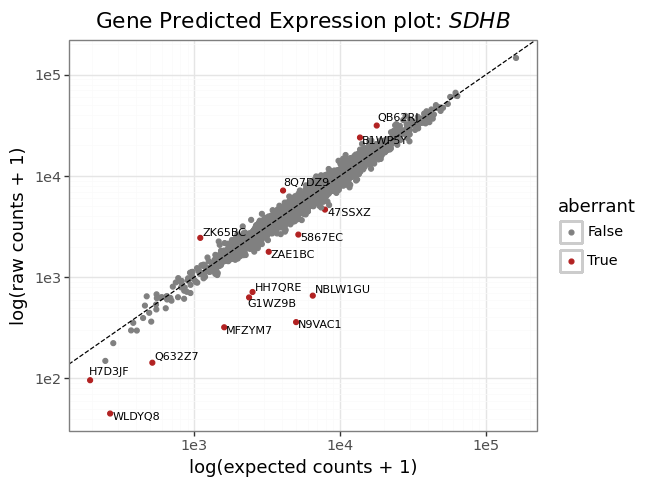

In [12]:
gene_name = "SDHB"
# plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]



p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(y = "raw_expression", x = "normalization_factors", color="aberrant")) + 
     pn.labs(y="log(raw counts + 1)", title=f"Gene Predicted Expression plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$", x="log(expected counts + 1)") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_x_log10() + 
     pn.scale_y_log10() + 
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw(base_size=13)
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            np.log10(row["normalization_factors"]), 
            np.log10(row["raw_expression"]),  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

In [ ]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "Rank", y=gene_id, color="aberrant")) + 
     pn.labs(y="Normalized counts + 1", title = "Expression rank cutoff: SDHB") +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["padjust"] <= 0.05]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["Rank"],
            row[gene_id],
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    expand_text=(1.2, 1.3)
)

# 🔑 show the *correct* figure
fig

In [ ]:
df = df.sort_values("raw_expression")
df["raw_rank"] = [i + 1 for i in range(df.shape[0])]


In [59]:
df[df["sampleID"] == "ZK65BC"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


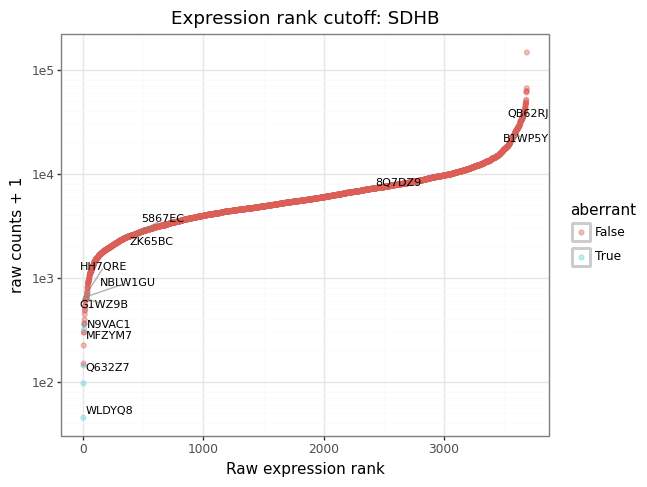

In [67]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "raw_rank", y="raw_expression", color="aberrant"), alpha=0.4) + 
     pn.labs(y="raw counts + 1", title = "Expression rank cutoff: SDHB", x="Raw expression rank") +
     pn.scale_y_log10() +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["padjust"] <= 0.05]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["raw_rank"], 
            np.log10(row["raw_expression"] + 1),  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

In [34]:
df[df["sampleID"] == "ZK65BC"]
# df[df["sampleID"] == "8Q7DZ9"]
# df[df["sampleID"] == "B1WP5Y"]
# df[df["sampleID"] == "QB62RJ"]



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [9]:
sample_id = "ZK65BC"
df = py_or_res[py_or_res["sampleID"] == sample_id]
df['-log10_p'] = -np.log10(df['pValue'])
df = df.merge(gene_annot_dt, left_on="geneID", right_on="gene_id", how="left")
# 2. Define the base plot
p = (
    pn.ggplot(df, pn.aes(x='zScore', y='-log10_p', color='aberrant'))
    + pn.geom_point(alpha=0.9)
    + pn.scale_color_manual(values={True: 'firebrick', False: 'lightgray'})
    + pn.labs(
        x="Z-Score",
        y="$-log_{10}(P-value)$",
        title=f"Volcano plot: {sample_id}"
    )
    + pn.theme_bw()
    + pn.theme(legend_position='bottom', figure_size=(8, 5))
)

# 3. Draw and access Matplotlib axes for text adjustment
fig = p.draw()
ax = fig.axes[0]

# 4. Filter for points to label (the aberrant ones)
aberrant_df = df[df["padjust"] <=  0.05]

print(len(aberrant_df))

aberrant_df = df[df["gene_name"] == "SDHB"]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["zScore"], 
            row["-log10_p"], 
            row["gene_name"], 
            fontsize=9,
            fontweight='bold',
            color='brown'
        )
    )

# 5. Adjust text to prevent overlapping
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="brown", lw=0.5),
    expand_points=(1.5, 1.5)
)

fig

PlotnineError: "Could not evaluate the 'color' mapping: 'aberrant' (original error: name 'aberrant' is not defined)"

In [12]:
gene_annot_dt[gene_annot_dt["gene_name"] == "ATM"]
gene_id = "ENSG00000117118.5"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt

gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)


normalization_factors = normalization_factors.T.rename(columns={gene_id: "normalization_factors"})
normalization_factors["sampleID"] = list(normalization_factors.index)
normalization_factors = normalization_factors.reset_index(drop=True)

df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")
df = df.merge(normalization_factors, on="sampleID")
df["aberrant"] = False
mask = (df["padjust_genes_of_interest"] <= 0.1)

# 2. Apply the mask to the 'aberrant' column and set to True
df.loc[mask, "aberrant"] = True

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


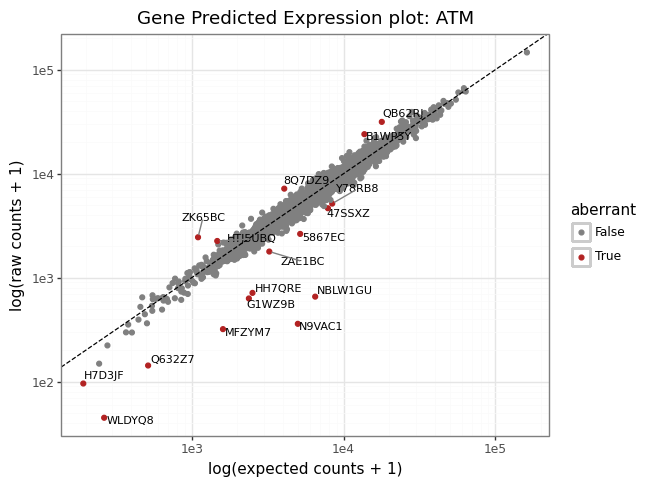

In [13]:
gene_name = "ATM"
# plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]

p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(y = "raw_expression", x = "normalization_factors", color="aberrant")) + 
     pn.labs(y="log(raw counts + 1)", title = f"Gene Predicted Expression plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$"", x="log(expected counts + 1)") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_x_log10() + 
     pn.scale_y_log10() + 
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            np.log10(row["normalization_factors"]), 
            np.log10(row["raw_expression"]),  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

# POLDI 

In [16]:
gene_annot_dt[gene_annot_dt["gene_name"] == "POLD1"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [12]:
gene_annot_dt[gene_annot_dt["gene_name"] == "POLD1"]
gene_id = "ENSG00000062822.8"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt

gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)


normalization_factors = normalization_factors.T.rename(columns={gene_id: "normalization_factors"})
normalization_factors["sampleID"] = list(normalization_factors.index)
normalization_factors = normalization_factors.reset_index(drop=True)

df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")
df = df.merge(normalization_factors, on="sampleID")
df["Underexpression outlier"] = False
mask = (df["padjust_genes_of_interest"] <= 0.1) & (df["zScore"] <= 0)

# 2. Apply the mask to the 'aberrant' column and set to True
df.loc[mask, "Underexpression outlier"] = True


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


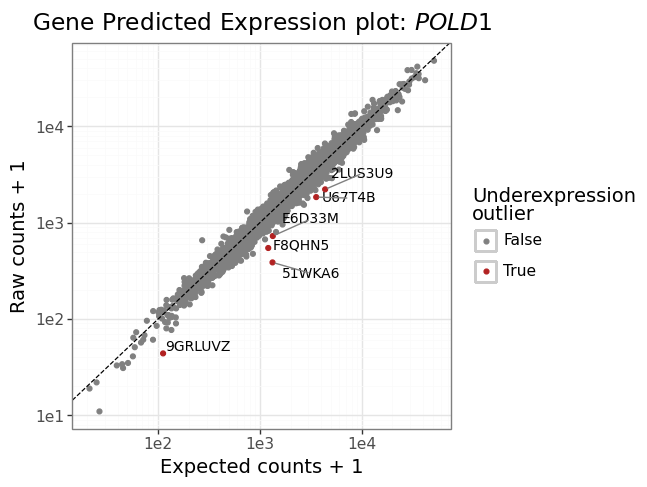

In [13]:
gene_name = "POLD1"


p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(y = "raw_expression", x = "normalization_factors", color="Underexpression outlier")) + 
     pn.labs(y="Raw counts + 1", title = f"Gene Predicted Expression plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$", x="Expected counts + 1",
            color="Underexpression\noutlier") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_x_log10() + 
     pn.scale_y_log10() + 
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw(base_size=14)
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["Underexpression outlier"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            np.log10(row["normalization_factors"]), 
            np.log10(row["raw_expression"]),  # <--- Transform this
            row["sampleID"],
            fontsize=10
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure

fig.savefig("/home/a379i/eshg/POLD1_expression.png", bbox_inches='tight', dpi=300)

# p.save(Scripts/AberrantSplicing/proportions_all_genes_underexpression_outliers.png", width=6, height=4, dpi=300)
fig


In [48]:
gene_id = "ENSG00000062822.8"
gene_name = "POLD1"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt



gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)


In [49]:
df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")

df["Underexpression outlier"] = False
mask = (df["padjust_genes_of_interest"] <= 0.05) & (df["zScore"] <= 0)

# 2. Apply the mask to the 'aberrant' column and set to True
df.loc[mask, "Underexpression outlier"] = True

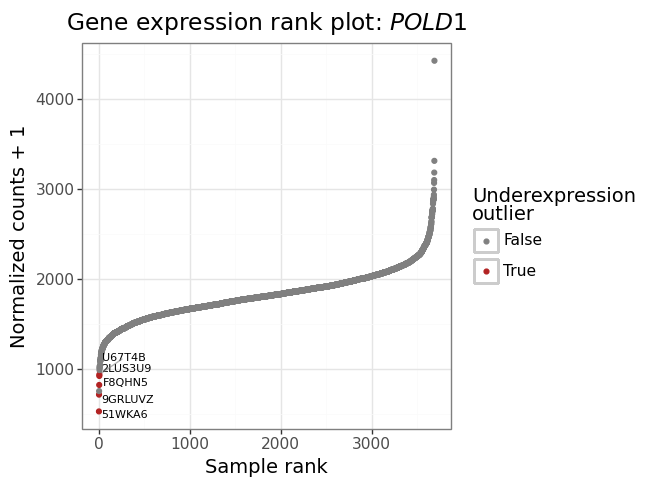

In [50]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "Rank", y=gene_id, color="Underexpression outlier")) + 
     pn.labs(y="Normalized counts + 1", title = f"Gene expression rank plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$", 
            color="Underexpression\noutlier",
            x = "Sample rank") +
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    

     pn.theme_bw(base_size=14)
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["Underexpression outlier"] == True]


texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["Rank"],
            row[gene_id],
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    expand_text=(1.2, 1.3)
)

# 🔑 show the *correct* figure
fig

# FH

In [10]:
gene_annot_dt[gene_annot_dt["gene_name"] == "MSH2"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [166]:
gene_id = "ENSG00000095002.8"
gene_name = "MSH2"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt

gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)


normalization_factors = normalization_factors.T.rename(columns={gene_id: "normalization_factors"})
normalization_factors["sampleID"] = list(normalization_factors.index)
normalization_factors = normalization_factors.reset_index(drop=True)

df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")
df = df.merge(normalization_factors, on="sampleID")
df["aberrant"] = False
mask = (df["padjust_predisp_extended"] <= 0.05) | (df["padjust"] <= 0.05)

# 2. Apply the mask to the 'aberrant' column and set to True
df.loc[mask, "aberrant"] = True

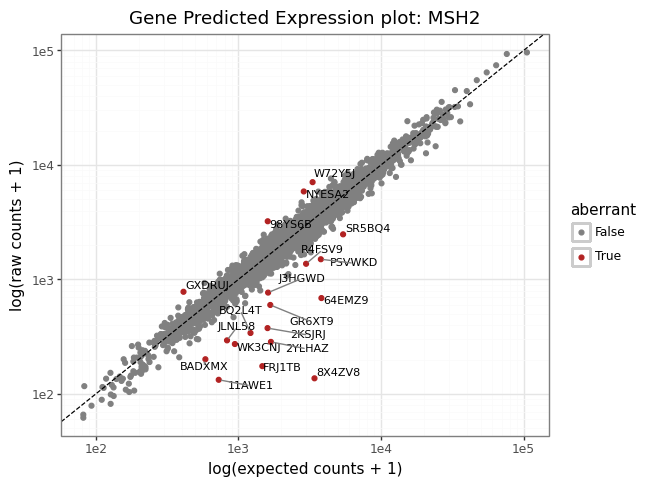

In [167]:
# plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]

p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(y = "raw_expression", x = "normalization_factors", color="aberrant")) + 
     pn.labs(y="log(raw counts + 1)", title = f"Gene Predicted Expression plot: {gene_name}", x="log(expected counts + 1)") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_x_log10() + 
     pn.scale_y_log10() + 
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            np.log10(row["normalization_factors"]), 
            np.log10(row["raw_expression"]),  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

In [168]:
py_or_res[(py_or_res["geneID"] == "ENSG00000095002.8") & (py_or_res["padjust_predisp_extended"] <= 0.05)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# WRN

In [24]:
gene_annot_dt[gene_annot_dt["gene_name"] == "FLCN"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [55]:
gene_id = "ENSG00000165392.5"
gene_name = "WRN"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [56]:
gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)

In [81]:
normalization_factors

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [57]:
df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")



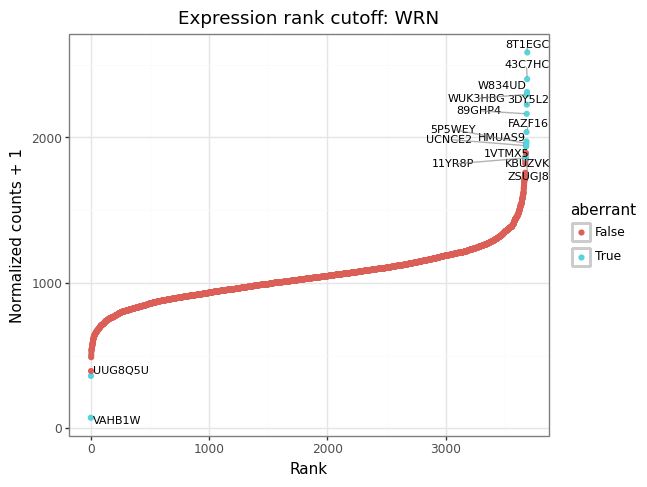

In [35]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "Rank", y=gene_id, color="aberrant")) + 
     pn.labs(y="Normalized counts + 1", title = f"Expression rank cutoff: {gene_name}") +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[(df["padjust_predisp_extended"] <= 0.05) | (df["padjust"] <= 0.05)]


texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["Rank"],
            row[gene_id],
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    expand_text=(1.2, 1.3)
)

# 🔑 show the *correct* figure
fig

In [60]:
df = df.sort_values("raw_expression")
df["raw_rank"] = [i + 1 for i in range(df.shape[0])]


In [61]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "raw_rank", y="raw_expression", color="aberrant"), alpha=0.4) + 
     pn.labs(y="raw counts + 1", title = f"Expression rank cutoff: {gene_name}", x="Raw expression rank") +
     pn.scale_y_log10() +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["padjust"] <= 0.05]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["raw_rank"], 
            np.log10(row["raw_expression"] + 1),  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

PlotnineError: "Could not evaluate the 'color' mapping: 'aberrant' (original error: name 'aberrant' is not defined)"

In [63]:
gene_annot_dt[gene_annot_dt["gene_name"] == "FLCN"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [112]:
len(extended_dresden_list)

252

# FLCN

In [64]:
gene_id = "ENSG00000154803.8"
gene_name = "FLCN"
raw = input_data[[gene_id]]
# raw

raw_dt = raw.rename(columns={gene_id: "raw_expression"})
raw_dt["sampleID"] = list(raw_dt.index)
raw_dt = raw_dt.reset_index(drop=True)
raw_dt



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [65]:
gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)

In [66]:
df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")

df["aberrant"] = False
mask = (df["padjust_predisp_extended"] <= 0.05) | (df["padjust"] <= 0.05)

# 2. Apply the mask to the 'aberrant' column and set to True
df.loc[mask, "aberrant"] = True

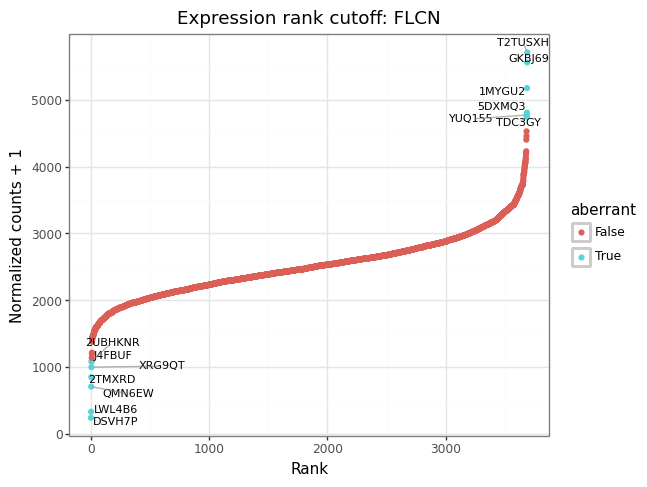

In [67]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "Rank", y=gene_id, color="aberrant")) + 
     pn.labs(y="Normalized counts + 1", title = f"Expression rank cutoff: {gene_name}") +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[(df["padjust_predisp_extended"] <= 0.05) | (df["padjust"] <= 0.05)]


texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["Rank"],
            row[gene_id],
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    expand_text=(1.2, 1.3)
)

# 🔑 show the *correct* figure
fig

In [68]:
df = df.sort_values("raw_expression")
df["raw_rank"] = [i + 1 for i in range(df.shape[0])]


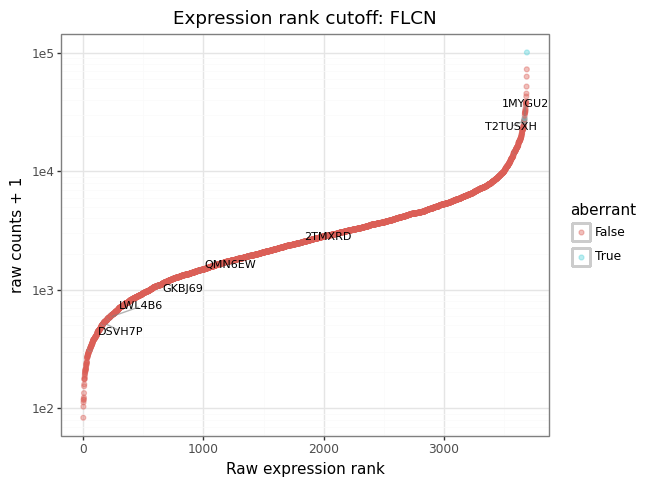

In [69]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "raw_rank", y="raw_expression", color="aberrant"), alpha=0.4) + 
     pn.labs(y="raw counts + 1", title = f"Expression rank cutoff: {gene_name}", x="Raw expression rank") +
     pn.scale_y_log10() +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["padjust"] <= 0.05]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["raw_rank"], 
            np.log10(row["raw_expression"] + 1),  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Protein expression

In [13]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants_predisppadjust_cnv.parquet")
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all = pd.merge(pr_res_all, sa, left_on="sampleID", right_on="pid")


pr_res_all.loc[ (pr_res_all["zScore"] <= 0) & (pr_res_all["padjust_predisp_extended"] <= 0.1) | (pr_res_all["padjust"] <= 0.1), "aberrant"] = True



In [16]:
plot_df[plot_df["sampleID"] == "22JTPS"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 52 rows containing missing values.


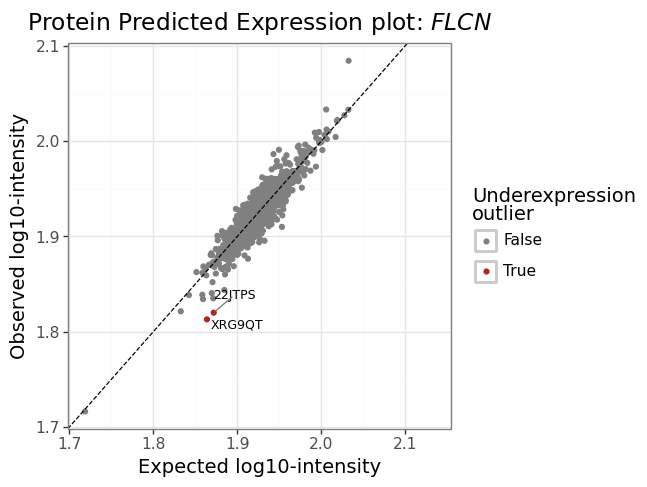

In [14]:
gene_name = "FLCN"

plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]

p = (pn.ggplot(plot_df) +
     pn.geom_point(pn.aes(y = "PROTEIN_LOG2INT", x = "PROTEIN_EXPECTED_LOG2INT", color="aberrant")) + 
     pn.labs(y="Observed log10-intensity", title = f"Protein Predicted Expression plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$", x="Expected log10-intensity", color="Underexpression\noutlier") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw(base_size=14)
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = plot_df[plot_df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["PROTEIN_EXPECTED_LOG2INT"], 
            row["PROTEIN_LOG2INT"],  # <--- Transform this
            row["sampleID"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)

fig.savefig("/home/a379i/eshg/FLCN_expression.png", bbox_inches='tight', dpi=400)

# 🔑 show the *correct* figure
fig

In [25]:
pr_res_all[pr_res_all["proteinID"] == "FLCN"].head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [11]:
df = pr_res_all[pr_res_all["proteinID"] == gene_name]
df = df.sort_values("raw_expression")
df["raw_rank"] = [i + 1 for i in range(df.shape[0])]



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


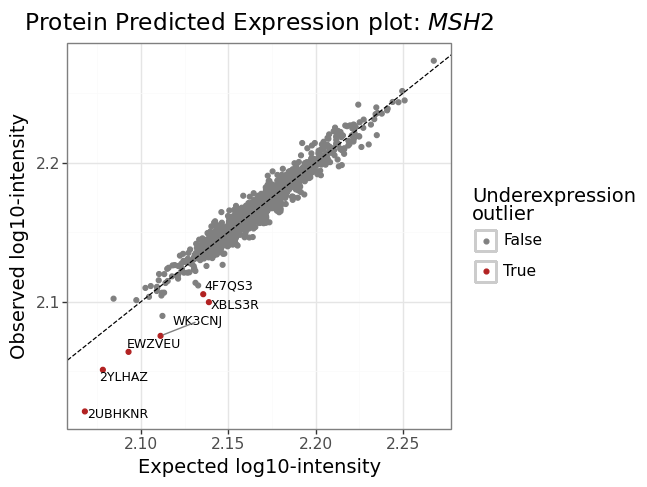

In [21]:
gene_name = "MSH2"

plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]

p = (pn.ggplot(plot_df) +
     pn.geom_point(pn.aes(y = "PROTEIN_LOG2INT", x = "PROTEIN_EXPECTED_LOG2INT", color="aberrant")) + 
     pn.labs(y="Observed log10-intensity", title = f"Protein Predicted Expression plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$", x="Expected log10-intensity", color="Underexpression\noutlier") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw(base_size=14)
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = plot_df[plot_df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["PROTEIN_EXPECTED_LOG2INT"], 
            row["PROTEIN_LOG2INT"],  # <--- Transform this
            row["sampleID"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)

fig.savefig("/home/a379i/eshg/MSH2_expression.png", bbox_inches='tight', dpi=400)

# 🔑 show the *correct* figure
fig

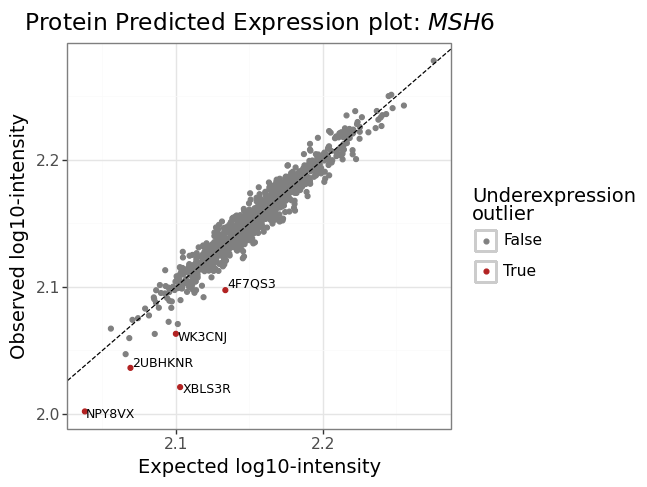

In [10]:
gene_name = "MSH6"

plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]

p = (pn.ggplot(plot_df) +
     pn.geom_point(pn.aes(y = "PROTEIN_LOG2INT", x = "PROTEIN_EXPECTED_LOG2INT", color="aberrant")) + 
     pn.labs(y="Observed log10-intensity", title = f"Protein Predicted Expression plot: $\\mathbf{{\\mathit{{{gene_name}}}}}$", x="Expected log10-intensity", color="Underexpression\noutlier") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw(base_size=14)
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = plot_df[plot_df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["PROTEIN_EXPECTED_LOG2INT"], 
            row["PROTEIN_LOG2INT"],  # <--- Transform this
            row["sampleID"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)

fig.savefig("/home/a379i/eshg/MSH6_expression.png", bbox_inches='tight', dpi=400)

# 🔑 show the *correct* figure
fig

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 145 rows containing missing values.


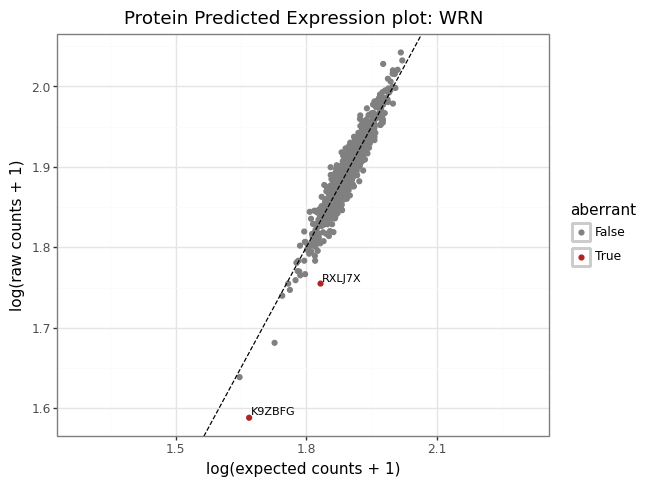

In [110]:
gene_name = "WRN"
plot_df = pr_res_all[pr_res_all["proteinID"] == gene_name]

p = (pn.ggplot(plot_df) +
     pn.geom_point(pn.aes(y = "PROTEIN_LOG2INT", x = "PROTEIN_EXPECTED_LOG2INT", color="aberrant")) + 
     pn.labs(y="log(raw counts + 1)", title = f"Protein Predicted Expression plot: {gene_name}", x="log(expected counts + 1)") +
     pn.geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
     pn.scale_color_manual(values={True: "firebrick", False: "grey"}) +    
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = plot_df[plot_df["aberrant"] == True]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["PROTEIN_EXPECTED_LOG2INT"], 
            row["PROTEIN_LOG2INT"],  # <--- Transform this
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray"),
    force_text=(0.5, 1), # Added a slight force to help movement
    expand_text=(1.2, 1.3)
)
# 🔑 show the *correct* figure
fig

In [106]:
pr_res_all[(pr_res_all["proteinID"] == "FLCN") & (py_or_res["sampleID"] == "22JTPS")]

/tmp/ipykernel_4089735/3970873782.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
